# Install dependencies

In [23]:
!pip3 install ultralytics

# Import modules

In [24]:
from ultralytics import YOLO
import os
from IPython.display import display
from PIL import Image

# Import Yolo Model

In [25]:
model_path = 'model/best.pt'
model = YOLO(model_path)

# Random Test Image

Using sample test image from validation set: dataset/valid/images/WhatsApp-Video-2026-07-28-at-7_49_49-PM_mp4-0004_jpg.rf.e9073e5c0777cdc2196229608db0b865.jpg


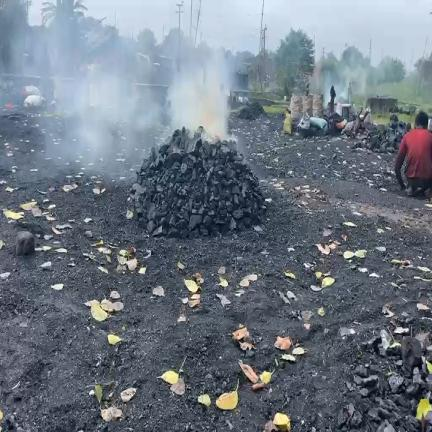

In [26]:
dataset_path = 'dataset'
validation_images_dir = os.path.join(dataset_path, 'valid', 'images')

# Get a list of images in the validation directory (assuming it's not empty)
if os.path.exists(validation_images_dir):
    all_images = [f for f in os.listdir(validation_images_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if all_images:
        # Pick the first image from the validation set for testing demonstration
        test_image_name = all_images[0]
        test_image_path = os.path.join(validation_images_dir, test_image_name)
        print(f"Using sample test image from validation set: {test_image_path}")
    else:
        test_image_path = "/content/path/to/your/test_image.jpg" # Placeholder if no images found
        print("No images found in validation set. Please update 'test_image_path' manually.")
else:
    test_image_path = "/content/path/to/your/test_image.jpg" # Placeholder if directory doesn't exist
    print("Validation image directory not found. Please update 'test_image_path' manually.")

display(Image.open(test_image_path))

# Custom Test Image

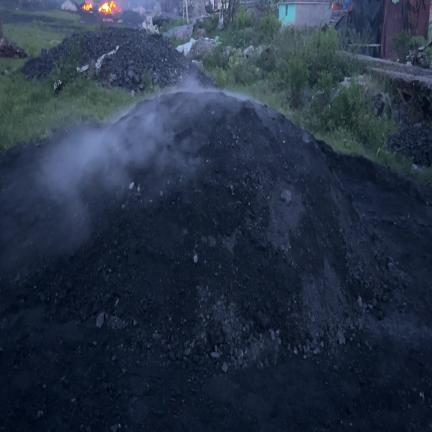

In [27]:
custom_test_image_path = "dataset/valid/images/IMG_7553_026_jpg.rf.f07eb5a301cf574265c6b04ad2a64961.jpg"
display(Image.open(custom_test_image_path))

# Generating Result

In [28]:
results = model.predict(source=test_image_path, conf=0.25)


image 1/1 /Users/zade/Projects/Spontaneous_Combustion_Detection_of_Coal/dataset/valid/images/WhatsApp-Video-2026-07-28-at-7_49_49-PM_mp4-0004_jpg.rf.e9073e5c0777cdc2196229608db0b865.jpg: 640x640 2 smokes, 38.2ms
Speed: 2.5ms preprocess, 38.2ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)


# Mapping out finding

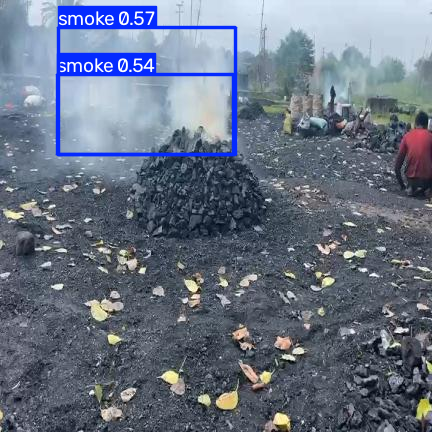

In [29]:
for r in results:
    im_array = r.plot() 
    display(Image.fromarray(im_array[..., ::-1]))